Données traitées et sauvegardées dans 'donnees_traitees_soufflerie.csv'.

 Voltage  Vitesse_testo  Pression_Pa  Vitesse_Pitot
    60.0           4.92    17.874746       5.458136
    57.5           4.68    16.057969       5.173324
    55.0           4.44    15.667264       5.110001
    52.5           4.20    13.987233       4.828256
    50.0           3.99    13.987233       4.828256
    47.5           3.77    12.092315       4.489305
    45.0           3.56    11.916497       4.456549
    42.5           3.34    10.138790       4.110716
    40.0           3.12     9.962973       4.074918
    35.0           2.72     8.028984       3.658092
    30.0           2.30     5.821502       3.114884
    20.0           1.47     3.086568       2.268101
    10.0           0.58     1.894918       1.777132
     0.0           0.00     0.000000       0.000000


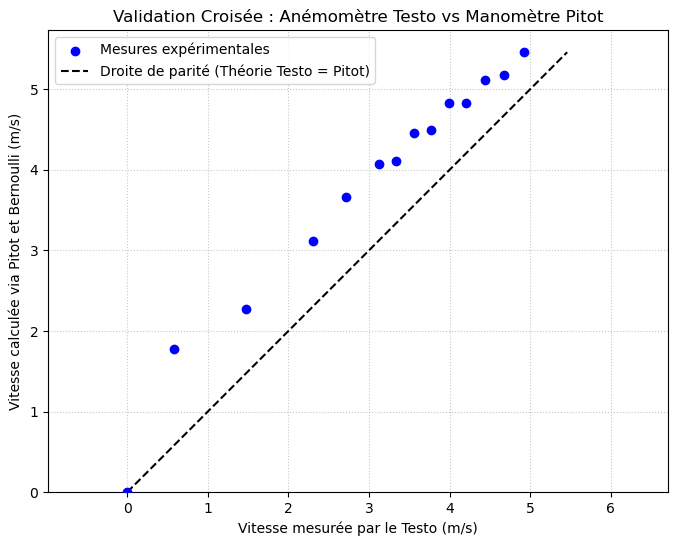

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import io

# 1. Tes données brutes (faciles à copier/coller)
csv_data = """Voltage,Vitesse_testo,Hauteur,Hauteur_2,Hauteur_3
60,4.92,0.6810,,
57.5,4.68,0.6903,,
55,4.44,0.6923,,
52.5,4.20,0.6965,0.7087,0.6975
50,3.99,0.7012,0.7006,
47.5,3.77,0.7106,,
45,3.56,0.7115,,
42.5,3.34,0.7206,,
40,3.12,0.7215,,
35,2.72,0.7314,,
30,2.30,0.7427,,
20,1.47,0.7567,,
10,0.58,0.7628,,
0,0, 0.7715,0.7688, 0.7772
"""

# 2. Paramètres physiques
RHO_ALCOOL = 784.0  # kg/m3 (calculé avec tes 24g/30ml)
RHO_AIR = 1.2       # kg/m3 (densité standard de l'air)
G = 9.81            # m/s2

# 3. Chargement et traitement des données
df = pd.read_csv(io.StringIO(csv_data))

# Calcule la moyenne des colonnes de hauteur (ignore automatiquement les valeurs manquantes)
df['Hauteur_Moyenne_in'] = df[['Hauteur', 'Hauteur_2', 'Hauteur_3']].mean(axis=1)

# Isole la valeur de référence (le Zéro) à la ligne où Voltage == 0
h0 = df.loc[df['Voltage'] == 0, 'Hauteur_Moyenne_in'].values[0]

# 4. Calculs physiques
# Delta H en pouces (Zéro - Valeur mesurée)
df['Delta_H_in'] = h0 - df['Hauteur_Moyenne_in']

# Delta H en mètres
df['Delta_H_m'] = df['Delta_H_in'] * 0.0254

# Pression Différentielle (Pascals) : dP = rho * g * h
df['Pression_Pa'] = RHO_ALCOOL * G * df['Delta_H_m']

# Vitesse calculée par Bernoulli : V = sqrt(2 * dP / rho_air)
# np.maximum(..., 0) empêche les erreurs de racine carrée sur des micro-valeurs négatives à 0V
df['Vitesse_Pitot'] = np.sqrt(np.maximum((2 * df['Pression_Pa']) / RHO_AIR, 0))

# 5. Sauvegarde du résultat
df_clean = df[['Voltage', 'Vitesse_testo', 'Pression_Pa', 'Vitesse_Pitot']]
df_clean.to_csv("donnees_traitees_soufflerie.csv", index=False)
print("Données traitées et sauvegardées dans 'donnees_traitees_soufflerie.csv'.\n")
print(df_clean.to_string(index=False))

# 6. Tracé du graphique de validation (Testo vs Pitot)
plt.figure(figsize=(8, 6))

# Nuage de points expérimental
plt.scatter(df['Vitesse_testo'], df['Vitesse_Pitot'], color='blue', label='Mesures expérimentales', zorder=3)

# Droite de parité (y = x) pour vérifier si Testo = Pitot
max_val = max(df['Vitesse_testo'].max(), df['Vitesse_Pitot'].max())
plt.plot([0, max_val], [0, max_val], 'k--', label='Droite de parité (Théorie Testo = Pitot)', zorder=2)

plt.title("Validation Croisée : Anémomètre Testo vs Manomètre Pitot")
plt.xlabel("Vitesse mesurée par le Testo (m/s)")
plt.ylabel("Vitesse calculée via Pitot et Bernoulli (m/s)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.axis('equal') # Force les axes à avoir la même échelle pour que la diagonale soit à 45°
plt.xlim(left=0)
plt.ylim(bottom=0)

plt.show()

<>:36: SyntaxWarning: invalid escape sequence '\D'
<>:36: SyntaxWarning: invalid escape sequence '\D'
C:\Users\alice\AppData\Local\Temp\ipykernel_6656\1096755547.py:36: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("Pression Différentielle $\Delta P$ (Pascals)")


============== RÉSULTATS D'ÉTALONNAGE ==============
Le coefficient moyen de ton tube de Pitot (Cp) est : 0.765



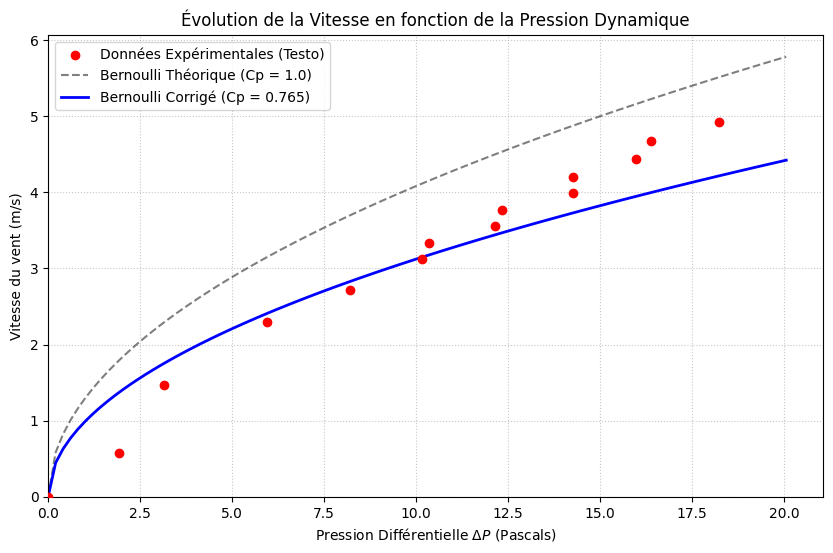

In [2]:
# --- SUITE DU SCRIPT PYTHON ---

# 1. Calcul du coefficient de calibration du Pitot (Cp)
# Cp = Vitesse_réelle (Testo) / Vitesse_théorique (Pitot)
# On ignore le point (0,0) pour éviter de diviser par zéro
df_valid = df[df['Vitesse_testo'] > 0].copy()
df_valid['Cp'] = df_valid['Vitesse_testo'] / df_valid['Vitesse_Pitot']

# Calcul du Cp moyen de ton installation
Cp_moyen = df_valid['Cp'].mean()
print(f"============== RÉSULTATS D'ÉTALONNAGE ==============")
print(f"Le coefficient moyen de ton tube de Pitot (Cp) est : {Cp_moyen:.3f}")
print("====================================================\n")

# 2. Tracé : Vitesse en fonction de la Pression (Courbe racine carrée)
plt.figure(figsize=(10, 6))

# A. Les points expérimentaux (Ce que le Testo a vraiment mesuré)
plt.scatter(df['Pression_Pa'], df['Vitesse_testo'], color='red', label='Données Expérimentales (Testo)', zorder=3)

# B. Générer une courbe lisse pour la théorie
# On crée 100 points de pression entre 0 et la pression max mesurée
P_max = df['Pression_Pa'].max() * 1.1 
P_lisse = np.linspace(0, P_max, 100)

# C. La courbe de Bernoulli pure (Théorie sans correction)
V_theorique = np.sqrt((2 * P_lisse) / RHO_AIR)
plt.plot(P_lisse, V_theorique, 'k--', alpha=0.5, label='Bernoulli Théorique (Cp = 1.0)')

# D. La courbe corrigée (Celle que tu utiliseras à l'avenir !)
V_corrigee = Cp_moyen * np.sqrt((2 * P_lisse) / RHO_AIR)
plt.plot(P_lisse, V_corrigee, 'b-', linewidth=2, label=f'Bernoulli Corrigé (Cp = {Cp_moyen:.3f})')

# Décoration du graphique
plt.title("Évolution de la Vitesse en fonction de la Pression Dynamique")
plt.xlabel("Pression Différentielle $\Delta P$ (Pascals)")
plt.ylabel("Vitesse du vent (m/s)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# On force l'origine du graphique à 0,0
plt.xlim(left=0)
plt.ylim(bottom=0)

plt.show()

<>:52: SyntaxWarning: invalid escape sequence '\D'
<>:52: SyntaxWarning: invalid escape sequence '\D'
C:\Users\alice\AppData\Local\Temp\ipykernel_6656\1973652651.py:52: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel("Pression Différentielle Mesurée $\Delta P$ (Pascals)")


============== RÉSULTATS D'ÉTALONNAGE CORRIGÉS ==============
Qualité de la droite (R²) : 0.9790
Le VRAI coefficient du Pitot (Cp) est : 0.932
L'erreur de Zéro (Shift du ménisque) était de : 2.40 Pascals



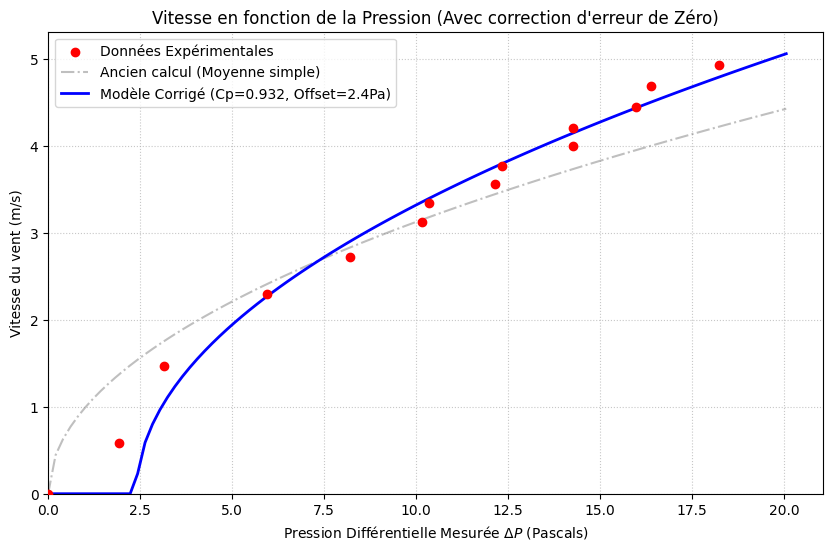

In [3]:
from scipy.stats import linregress

# --- NOUVELLE MÉTHODE D'ÉTALONNAGE : LA LINÉARISATION ---

# 1. On ignore le point (0,0) artificiel pour la régression
df_fit = df[df['Vitesse_testo'] > 0].copy()

# 2. On prépare nos axes X et Y
X_Pression = df_fit['Pression_Pa']
Y_Vitesse_Carree = df_fit['Vitesse_testo']**2

# 3. Régression Linéaire (Y = m*X + c)
pente, intercept, r_value, p_value, std_err = linregress(X_Pression, Y_Vitesse_Carree)

# 4. Extraction de la Physique à partir des Maths
# Pente m = (2 * Cp^2) / rho_air  ==>  Cp = sqrt((m * rho_air) / 2)
Cp_vrai = np.sqrt((pente * RHO_AIR) / 2)

# Intercept c = - m * P_offset ==> P_offset = -c / m
P_offset = -intercept / pente

print(f"============== RÉSULTATS D'ÉTALONNAGE CORRIGÉS ==============")
print(f"Qualité de la droite (R²) : {r_value**2:.4f}")
print(f"Le VRAI coefficient du Pitot (Cp) est : {Cp_vrai:.3f}")
print(f"L'erreur de Zéro (Shift du ménisque) était de : {P_offset:.2f} Pascals")
print("==============================================================\n")

# --- TRACÉ DU NOUVEAU GRAPHIQUE ---
plt.figure(figsize=(10, 6))

# A. Les points expérimentaux bruts
plt.scatter(df['Pression_Pa'], df['Vitesse_testo'], color='red', label='Données Expérimentales', zorder=3)

# B. Génération de l'axe X lisse
P_max = df['Pression_Pa'].max() * 1.1 
P_lisse = np.linspace(0, P_max, 100)

# C. L'ancienne courbe qui marchait mal (celle de ton image)
Cp_moyen_basique = (df_fit['Vitesse_testo'] / df_fit['Vitesse_Pitot']).mean()
V_ancienne = Cp_moyen_basique * np.sqrt((2 * P_lisse) / RHO_AIR)
plt.plot(P_lisse, V_ancienne, 'gray', linestyle='-.', alpha=0.5, label='Ancien calcul (Moyenne simple)')

# D. LA NOUVELLE COURBE MAGIQUE (qui inclut le Cp ET le Shift)
# On s'assure de ne pas faire de racine de nombre négatif
P_lisse_corrige = np.maximum(P_lisse - P_offset, 0) 
V_nouvelle = Cp_vrai * np.sqrt((2 * P_lisse_corrige) / RHO_AIR)

plt.plot(P_lisse, V_nouvelle, 'blue', linewidth=2, label=f'Modèle Corrigé (Cp={Cp_vrai:.3f}, Offset={P_offset:.1f}Pa)')

# Décoration
plt.title("Vitesse en fonction de la Pression (Avec correction d'erreur de Zéro)")
plt.xlabel("Pression Différentielle Mesurée $\Delta P$ (Pascals)")
plt.ylabel("Vitesse du vent (m/s)")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.xlim(left=0)
plt.ylim(bottom=0)

plt.show()

=== ÉQUATION DE LA SOUFFLERIE ===
V(V_gen) = 0.00017 * V_gen² + 0.0724 * V_gen + -0.056


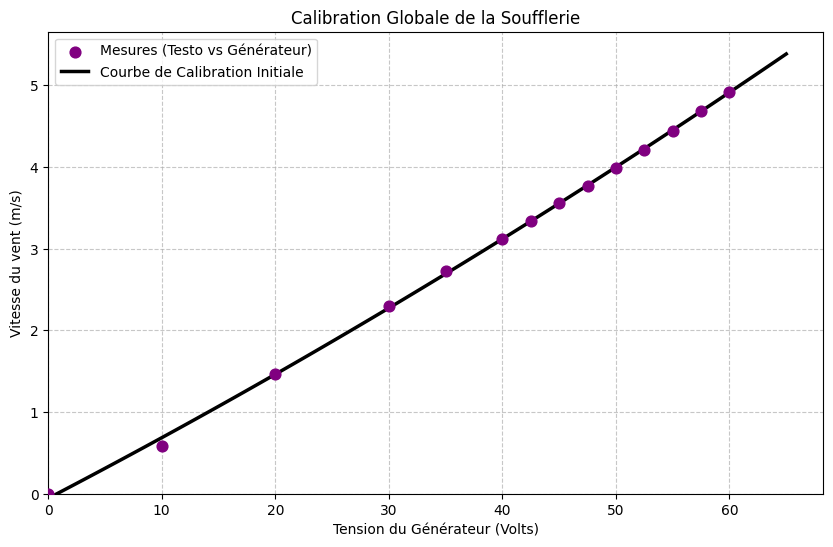

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. On utilise tes données (Générateur vs Testo)
X_Voltage = df['Voltage']
Y_Vitesse = df['Vitesse_testo']

# 2. On fait un ajustement polynomial de degré 2 (y = ax^2 + bx + c)
# C'est la forme classique pour la courbe de puissance d'un ventilateur
coefs = np.polyfit(X_Voltage, Y_Vitesse, 2)
poly_func = np.poly1d(coefs)

print(f"=== ÉQUATION DE LA SOUFFLERIE ===")
print(f"V(V_gen) = {coefs[0]:.5f} * V_gen² + {coefs[1]:.4f} * V_gen + {coefs[2]:.3f}")
print("=================================")

# 3. Tracé de la Courbe Maîtresse
plt.figure(figsize=(10, 6))

# Tes points expérimentaux purs
plt.scatter(X_Voltage, Y_Vitesse, color='purple', s=60, label='Mesures (Testo vs Générateur)', zorder=3)

# La courbe lisse de calibration
V_lisse = np.linspace(0, 65, 100)
plt.plot(V_lisse, poly_func(V_lisse), 'k-', linewidth=2.5, label='Courbe de Calibration Initiale')

plt.title("Calibration Globale de la Soufflerie")
plt.xlabel("Tension du Générateur (Volts)")
plt.ylabel("Vitesse du vent (m/s)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(left=0)
plt.ylim(bottom=0)

plt.show()

### 